# Lexos API Dendrogram Tutorial

### 1. Setting Up Your Environment: The Essential Tools
Before we dive into analyzing texts, we need to make sure you have the necessary "tools" installed on your computer. These are software libraries that `lexos` relies on to do its work.
 
Important: These commands need to be run in your command line (also known as your terminal or console), not directly in this Jupyter Notebook. Open your command line program and type these commands, pressing Enter after each one:


### 2. Loading Our Libraries: Getting Ready to Work
Now that the tools are installed, let's load them into our Jupyter Notebook environment.
Run the following code cell:

In [1]:
import spacy
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

# Assuming lexos is installed, or the lexos folder is in your Python path
# For this tutorial, we'll assume the `lexos` package is available.
# If you're running this from the lexos source code directory, you might need to
# adjust your Python path or ensure lexos is installed.
try:
    from lexos.dtm import DTM
    from lexos.cluster.dendrogram import Dendrogram
    from lexos.exceptions import LexosException
except ImportError:
    print("Could not import Lexos modules. Make sure 'lexos' is installed or accessible.")
    print("You might need to run: pip install lexos")

nlp = spacy.load("en_core_web_sm")

### 3. Gathering Our Texts: The Documents for Analysis

Next, we need to tell `lexos` which text files we want to analyze. For this tutorial, we'll use a few classic literary works as examples. We'll store their locations in a Python dictionary.
 
A **dictionary** is like a list where each item has a unique **label** (like "Poe" or "Irving") that helps us find its corresponding **value** (the actual path to the text file on your computer). These labels will become the names of your documents in the final dendrogram.

**Important Note for Your Own Texts:** If you replace these example files with your own custom texts, please be aware that `spaCy` (the text processing library) has a default safety limit of **1,000,000 characters** per document. Very, very long documents might need special handling, but for most literary works, this limit is generous.
 
**Before running this cell, make sure the file paths are correct for where you've saved these example texts on your computer!** If you move this Jupyter Notebook, you might need to adjust the paths to point to the correct locations.


In [ ]:
from pathlib import Path

# Load text files from uploaded documents.
# The 'key' (e.g., "Poe") will be our document label.
# The 'value' is the path to the text file.
files = {
    "Poe": "FilesToUse/Poe_FallOfHouseUsher_1839.txt",
    "Lippard": "FilesToUse/Lippard_BelOfPrairieEden.txt",
    "Irving": "FilesToUse/Irving_RipVanWInkle.txt",
    "Henry": "FilesToUse/HenryWP_ThePirate.txt",
}

# Read the content of each text file into a list of strings
docs = [Path(path).read_text(encoding="utf-8") for path in files.values()]

# Get the labels (names) for each document directly from our dictionary's keys
labels = list(files.keys())

print(f"Loaded {len(docs)} documents with labels: {labels}")

Loaded 4 documents with labels: ['Poe', 'Lippard', 'Irving', 'Henry']


### 4. Creating the Document-Term Matrix (DTM): Our Linguistic "Spreadsheet"

 Before we can build a dendrogram, we need to transform our raw text documents into a structured numerical format that computers can understand. This is where the **Document-Term Matrix (DTM)** comes in.
 
 Imagine a giant spreadsheet (a matrix) where:
 * Each **row** represents one of your documents (e.g., "Poe", "Irving").
 * Each **column** represents a unique "term" (usually a word) found across all your documents.
 * Each **cell** contains a number indicating how many times that specific "term" appears in that specific document.
 
 This matrix is the foundation for analyzing textual relationships.
 
 #### What is a "Term" and How Do We Prepare Our Texts?
 
 In this context, a "term" is typically a word. However, before counting words, `lexos` (using `spaCy` behind the scenes) performs several crucial **pre-processing** steps. These steps clean and standardize your text, ensuring that the counts are meaningful for analysis.
 
 Here are some important pre-processing options you can control when creating the DTM:
 
 * **`stop_words`**: These are very common words (like 'a', 'an', 'the', 'is', 'and', 'but') that appear frequently in almost all texts and often don't carry much unique meaning for distinguishing between documents.
     * **`True` (default)**: Removes these common words.
     * **`False`**: Keeps all words.
     * *Why use it?* Removing stop words helps you focus on the more distinctive vocabulary that truly characterizes your texts.
 
 * **`lemmatize`**: This reduces words to their **base form** (their "lemma"). For example, 'running', 'ran', and 'runs' would all become 'run'.
     * **`True`**: Words are lemmatized.
     * **`False` (default)**: Words are not lemmatized.
     * *Why use it?* If you want to analyze concepts regardless of their grammatical variations, lemmatization is very useful. For instance, focusing on the concept of "fear" rather than distinguishing between "fear," "fears," and "feared."
 
 * **`pos_filter`**: This allows you to include only terms that are specific **Parts-of-Speech (POS)**, like nouns, verbs, adjectives, etc.
     * You provide a list of desired POS tags (e.g., `['NOUN', 'VERB', 'ADJ']`).
     * *Why use it?* If you're interested in how documents relate based only on the **objects** they discuss (nouns), the **actions** they describe (verbs), or the **qualities** they assign (adjectives), this filter is incredibly powerful.
 
 * **`min_freq` / `max_freq`**: These settings control the frequency of terms included in the DTM.
     * **`min_freq`**: The minimum number of times a term must appear *across all documents* to be included. Setting `min_freq=2` would remove unique misspellings or rare words that might not be significant.
     * **`max_freq`**: The maximum proportion of documents a term can appear in. Setting `max_freq=0.8` (0.8 or 80%) would remove terms that appear in almost every document, acting almost like custom stop words for your specific dataset.
     * *Why use them?* To focus on terms that are neither too rare (potentially noise) nor too common (not distinctive).
 
 * **`ngrams`**: This allows you to treat **phrases** (sequences of words) as single "terms" in your DTM, rather than just individual words.
     * You provide a tuple like `(1, 2)`: `1` includes single words (unigrams), and `2` includes two-word phrases (bigrams). `(2, 3)` would include two- and three-word phrases.
     * *Why use it?* Captures collocations and common phrases that might carry more meaning than individual words (e.g., "dark forest" vs. "dark" and "forest" separately).
 
#### Creating Our DTM

Let's create our DTM. In this example, we'll start with the default settings for `stop_words` and `lemmatize` (which means stop words *will* be removed and lemmatization *will not* be applied by default in Lexos's DTM, but you can change it!). We'll use `nlp(doc)` to first process each raw text string into a `spaCy` document object.


In [3]:
# Create an instance of the DTM object
dtm = DTM()

# Process our documents with spaCy and then create the DTM.
# We'll use default settings for now, but you can uncomment and adjust parameters below!
dtm(
    docs=[nlp(doc) for doc in docs], # First, process each text with spaCy
    labels=labels,                     # Use our defined document labels
    # Here are some optional parameters you can uncomment and try:
    # stop_words=True,   # Remove common words like 'the', 'is', 'and' (True by default in Lexos DTM)
    # lemmatize=True,    # Convert words to their base form (e.g., 'running' -> 'run')
    # pos_filter=['NOUN', 'VERB', 'ADJ'], # Only include nouns, verbs, and adjectives
    # min_freq=2,        # Only include terms that appear at least 2 times overall
    # ngrams=(1, 2)      # Include single words (unigrams) and two-word phrases (bigrams)
)

print(f"DTM created with {dtm.to_df().shape[0]} documents and {dtm.to_df().shape[1]} unique terms.")


DTM created with 7713 documents and 4 unique terms.


### 5. Generating the Dendrogram: Visualizing Textual Relationships
 
 Now for the exciting part: generating and displaying your Dendrogram! This tree visually represents the relationships between your documents based on the numerical data in our DTM.
 
 When we create the `Dendrogram`, we need to tell it how to measure document similarity and how to connect those similarities into a tree. Here are the key parameters you can adjust:
 
 * **`dtm`**: This is our "linguistic spreadsheet" (`dtm`) that we created in the previous step. It's the essential input for the tree.
 
 * **`metric`**: This tells the dendrogram how to measure the "distance" or dissimilarity between your documents. Shorter distances mean more similar documents.
     * **`"euclidean"` (default)**: Think of this as the "straight-line" distance between two points on a graph. It's good for general comparisons but can be sensitive to the overall length of documents (longer documents might naturally have larger term counts, increasing their "distance").
     * **`"cosine"`**: Imagine each document as an arrow pointing in a specific linguistic "direction." Cosine similarity measures how much these arrows point in the same direction. If they point almost identically, the documents are very similar, even if one document is much longer than another. This is often an excellent choice for text analysis as it focuses on stylistic or thematic *direction* rather than raw word counts.
     * **`"cityblock"`** (also called Manhattan distance): Imagine moving on a city grid where you can only go along streets (no diagonal shortcuts). This distance is the sum of the absolute differences for each term between two documents. Useful when the individual differences in term counts are important.
     * Many other metrics are available (e.g., "jaccard", "chebyshev"). You can find a full list in the SciPy documentation for `scipy.spatial.distance.pdist`.
 
 * **`method`**: Once we've measured distances, this method determines how individual documents (or existing clusters of documents) are joined together to form larger branches and clusters in the tree.
     * **`"average"` (default)**: When combining two clusters, this method considers the average distance between *all* pairs of documents in the two clusters. It tends to produce well-balanced clusters.
     * **`"single"`**: Joins clusters based on the *closest* pair of documents between them. This can sometimes lead to "chaining," where documents connect one after another, forming long, straggly branches.
     * **`"complete"`**: Joins clusters based on the *farthest* pair of documents between them. This tends to produce more compact, spherical clusters, ensuring all documents within a cluster are relatively similar to each other.
     * **`"ward"`**: This method aims to minimize the increase in "variance" (or spread) within clusters when they are merged. It tries to make clusters that are as "tight" and internally similar as possible. Often produces intuitive and well-structured clusters.
     * Many other methods are available. You can find a full list in the SciPy documentation for `scipy.cluster.hierarchy.linkage`.
 
 * **`labels`**: This is simply the list of descriptive names for your documents (e.g., "Poe", "Lippard") that we defined earlier. These will appear as the leaves (endpoints) on your tree.
 
 * **`orientation`**: Controls the direction of the dendrogram.
     * **`"top"` (default)**: Branches extend downwards from the top.
     * **`"bottom"`**: Branches extend upwards from the bottom.
     * **`"left"`**: Branches extend rightwards from the left.
     * **`"right"`**: Branches extend leftwards from the right.
 
 * **`color_threshold`**: If set, branches with a distance below this threshold will be colored differently from those above it. This helps visualize clusters at a certain distance level. You can try a number like `1.0` or `1.5` to see its effect.
 
 * **`show`**: Controls whether the generated tree figure is displayed directly in this Jupyter Notebook cell.
     * **`True`**: The tree will appear right below the code cell.
     * **`False` (default)**: The tree will not be shown immediately. This is useful if you just want to save the figure to a file without displaying it in the notebook. If you set `show=False`, remember to call `dendrogram.showfig()` later to display it.
 
 * **`title`**: Adds a title to your dendrogram plot.
 
 * **`figsize`**: A tuple `(width, height)` in inches to set the size of the overall figure. For example, `(12, 8)` for a wider and taller plot.
 
 Let's generate our first Dendrogram! We'll start with common parameters, but feel free to come back and experiment with them.


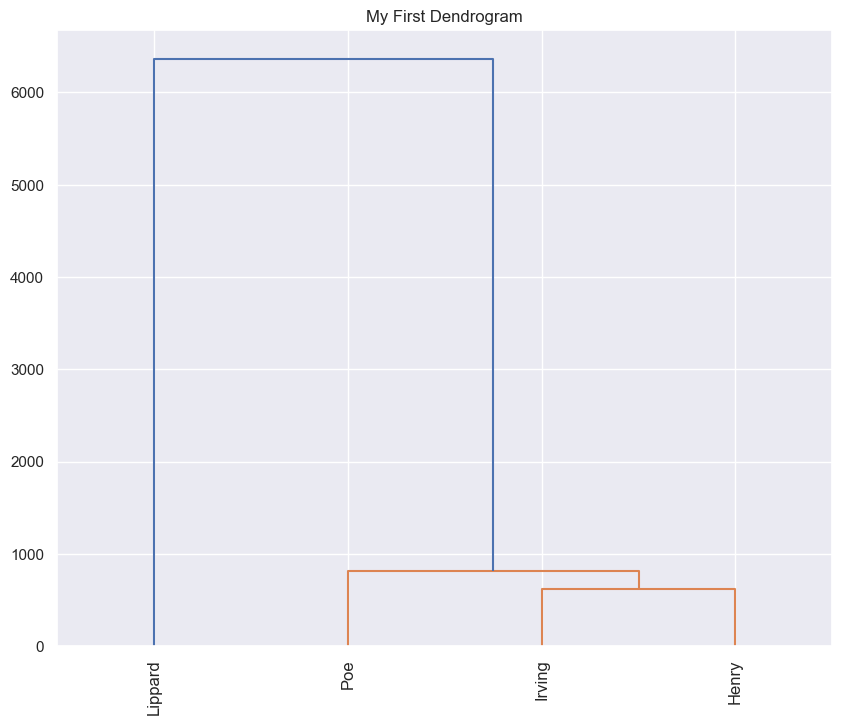

In [4]:
# Create an instance of the Dendrogram object
dendrogram = Dendrogram()

# Generate the Dendrogram.
# Experiment with the parameters below!
try:
    dendrogram(
        dtm=dtm,
        labels=labels,
        metric="euclidean",   # Try "cosine" for stylistic comparisons, or "cityblock"
        method="average",     # Try "ward" for compact clusters, or "complete"
        orientation="top",    # Try "left" or "right"
        # color_threshold=1.5, # Uncomment and set a number to color branches
        title="My First Dendrogram",
        figsize=(10, 8),      # Adjust figure size for better readability
        show=True             # Display the figure in the notebook
    )
    
    # If show=False was used in the Dendrogram call, you can explicitly show the figure like this:
    # dendrogram.showfig() 
except LexosException as e:
    print(f"An error occurred while generating the dendrogram: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


### 6. Interpreting Your Dendrogram
 
 Now that you've generated the tree, let's talk about how to read it!
 
 The tree you see is a **dendrogram**, a type of tree diagram that shows hierarchical clustering.
 
 * **Leaves (Document Labels)**: At the very end of each branch, you'll see your document labels (Poe, Lippard, Irving, Henry). These are your individual texts.
 * **Branches and Nodes (Clusters)**: The lines that connect documents and other branches represent clusters. When branches merge, it means the documents or clusters they represent are being grouped together.
 * **Branch Lengths (Dissimilarity/Distance)**: The vertical length of a branch (or horizontal length if `orientation` is "left" or "right") indicates the **distance** or **dissimilarity** between the documents or clusters it connects.
     * **Shorter vertical branches** mean that the documents or clusters are **more similar** to each other based on their linguistic features. They are "closer."
     * **Longer vertical branches** mean that the documents or clusters are **less similar** to each other. They are "further apart."
 
 **How to Read the Tree:**
 
 Start from the leaves (your document names) and move up towards the root of the tree (or left if `orientation` is "right", etc.).
 1.  **Closest Relatives:** Look for the first merges. Documents that merge first (i.e., they are connected by a short branch) are the most similar to each other based on the chosen `metric`.
 2.  **Broader Groupings:** As you move further up, you'll see larger branches forming, grouping together sets of documents or smaller clusters. These broader groupings represent larger patterns of similarity.
 
 **Example Interpretation (based on typical results for these texts):**
 
 You might observe that "Poe" and "Lippard" are clustered together with a relatively short branch length, suggesting a linguistic similarity. Then, perhaps "Irving" joins that cluster, indicating it's somewhat similar to the Poe/Lippard group but less so than they are to each other. "Henry" might be an outlier, joining the main cluster with a much longer branch, indicating it's quite distinct linguistically from the others in this sample.
 
 **What Your Tree Might Tell You:**
 
 * **Stylistic Similarities:** Are authors from the same period or literary movement clustering together?
 * **Genre Influence:** Do texts of a particular genre (e.g., gothic horror) form a distinct cluster?
 * **Thematic Patterns:** If you used POS filtering or focused on specific terms, does the tree reveal groupings based on shared themes or subject matter?


### 7. Customizing Your Visualization: Making the Tree Your Own
 
 The `lexos` Dendrogram uses `matplotlib` to create the plot, which means you have a lot of control over its appearance. While `lexos` sets sensible defaults, you can easily tweak things like font size, leaf rotation, and overall figure size for better readability or presentation.
 
 #### Adjusting Font Size and Leaf Rotation
 
 Sometimes, the labels on the tree can be small or overlap. You can adjust the font size of the leaf labels (your document names) and rotate them for better readability.
 
 * **`leaf_font_size`**: Sets the font size for the document labels.
 * **`leaf_rotation`**: Rotates the leaf labels. A value of `90` is common for vertical labels when the `orientation` is "top" or "bottom".


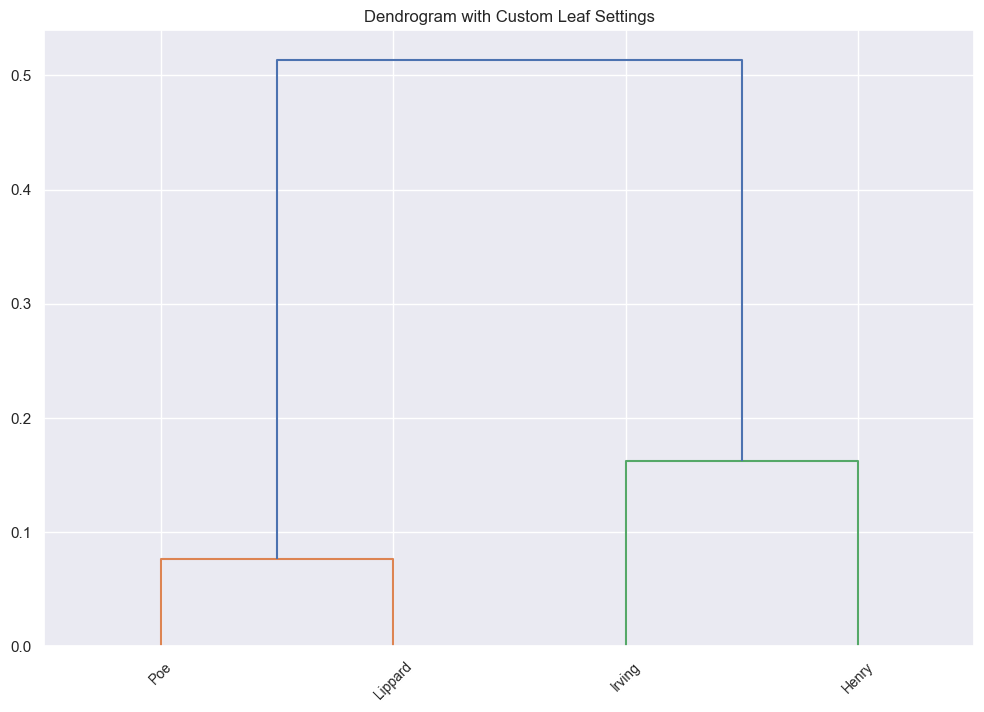

In [5]:
# You can generate a new dendrogram with adjusted settings
try:
    dendrogram_custom_font = Dendrogram()
    dendrogram_custom_font(
        dtm=dtm,
        labels=labels,
        metric="cosine",
        method="ward",
        orientation="top",
        leaf_font_size=10,    # Make labels slightly larger
        leaf_rotation=45,     # Rotate labels for better fit
        title="Dendrogram with Custom Leaf Settings",
        figsize=(12, 8),
        show=True
    )
except LexosException as e:
    print(f"An error occurred: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


#### Adjusting Figure Size
 
 If your tree has many documents or long labels, it might feel cramped. You can make the overall figure wider or taller to give it more space using the `figsize` parameter directly when you create the `Dendrogram` instance.


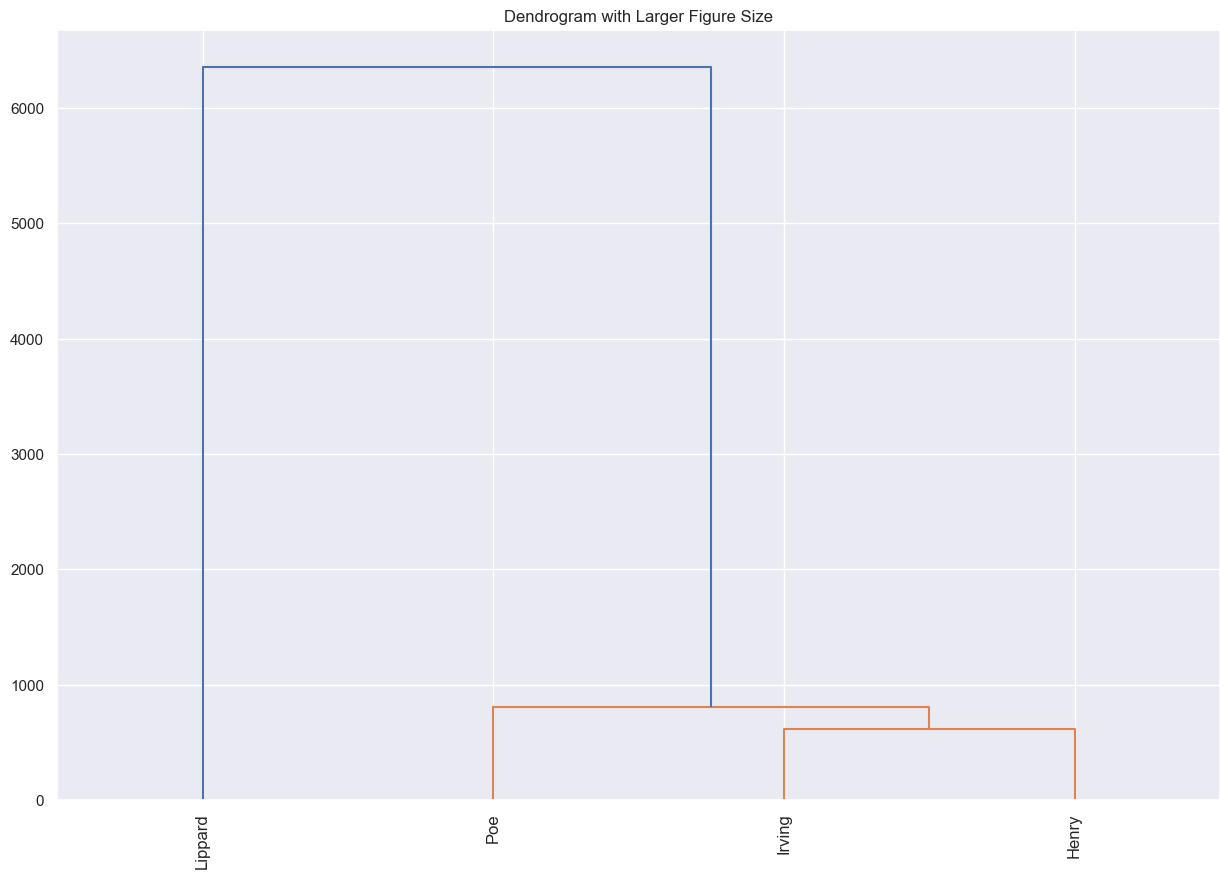

In [6]:
# Example: Make the figure 15 inches wide and 10 inches tall
try:
    dendrogram_large_fig = Dendrogram()
    dendrogram_large_fig(
        dtm=dtm,
        labels=labels,
        metric="euclidean",
        method="average",
        title="Dendrogram with Larger Figure Size",
        figsize=(15, 10), # Set width and height here
        show=True
    )
except LexosException as e:
    print(f"An error occurred: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

### 8. Saving Your Tree: Keeping Your Results
 
 Once you're happy with your Dendrogram, you'll likely want to save it as an image file for reports, presentations, or simply for your records.
 
 The `dendrogram.save()` method allows you to do this easily. Just provide a file name (including the extension), and it will save the image. You can choose different file formats by changing the extension (e.g., `.png`, `.jpg`, `.pdf`, `.svg`). PNG is generally a good choice for web or documents, while SVG provides a scalable vector graphic useful for high-quality printing.


In [7]:
try:
    # Save the last generated dendrogram figure
    # You can choose the filename and format
    dendrogram_large_fig.save("my_dendrogram_analysis_result.png") 

    print("Dendrogram saved as 'my_dendrogram_analysis_result.png' in your notebook's directory.")
except LexosException as e:
    print(f"Could not save the figure: {e}")
except AttributeError:
    print("No figure to save. Make sure you've successfully generated a dendrogram first.")


Dendrogram saved as 'my_dendrogram_analysis_result.png' in your notebook's directory.


### 9. Troubleshooting
 
 **"My tree looks blank or empty!"**
 * **Verify DTM:** Ensure your `dtm` was created successfully and contains terms. If your documents are very short or very similar, the DTM might be sparse.
 * **Check `show=True`**: Make sure you set `show=True` when calling the `Dendrogram` instance, or explicitly call `dendrogram.showfig()` after creating it.
 
 **"My documents don't cluster the way I expected!"**
 * **Experiment with `metric` and `method`**: Different distance metrics and linkage methods reveal different aspects of similarity. `"cosine"` often works well for stylistic analysis of texts. `"ward"` or `"average"` are generally good linkage methods.
 * **Adjust DTM pre-processing**: Try different combinations of `stop_words`, `lemmatize`, `pos_filter`, `min_freq`, and `ngrams` when creating your DTM. The choice of "terms" is paramount to the relationships you uncover. For example, if you're interested in character interactions, perhaps filtering for proper nouns and verbs would be revealing.
 
 **"I'm getting errors about Lexos modules not found."**
 * Ensure you have installed `lexos`. If not, run `pip install lexos` in your command line.